# Notebook 12: Feature Relationships

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What are Feature Relationships?

Before training a model, we must understand two kinds of relationships:
1. **Feature vs target:** which features actually help predict the target?
2. **Feature vs feature:** are some features duplicates of each other?

**Analogy:** You are choosing a team for a quiz. You want players who know different subjects. Two players who know exactly the same things add no value, and a player who knows nothing relevant only adds noise.

**Why it matters in AI/ML:** Useful features improve accuracy, redundant features make linear models unstable and harder to explain, and irrelevant features cause overfitting and slow training.

**Topics covered:** Correlation Matrix, Multicollinearity, Variance Inflation Factor (VIF), Feature Importance, Feature Selection Basics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import (VarianceThreshold, SelectKBest,
                                       f_regression, mutual_info_regression, RFE)

np.random.seed(42)
n = 500

area = np.random.uniform(500, 3000, n)                       # sq ft
bedrooms = np.clip(np.round(area / 800 + np.random.normal(0, 0.5, n)), 1, 6)
area_sqm = area * 0.0929 + np.random.normal(0, 5, n)         # same info in another unit
distance = np.random.uniform(1, 25, n)                       # km from city centre
age = np.random.uniform(0, 40, n)                            # building age
noise_feature = np.random.normal(0, 1, n)                    # unrelated to price
constant_col = np.ones(n)                                    # never changes

price = 0.05 * area + 2 * bedrooms - 0.8 * distance - 0.3 * age + np.random.normal(0, 5, n)

df = pd.DataFrame({
    "area": area, "area_sqm": area_sqm, "bedrooms": bedrooms,
    "distance": distance, "age": age,
    "noise_feature": noise_feature, "constant_col": constant_col,
    "price": price,
})
print(df.head())
print("\nShape:", df.shape)

          area    area_sqm  bedrooms   distance        age  noise_feature  \
0  1436.350297  136.356584       2.0  16.280072  38.861308      -1.598124   
1  2876.785766  265.456937       5.0  15.734406  13.253880       0.462173   
2  2329.984855  219.408867       3.0   2.599649  19.281642       2.024310   
3  1996.646210  191.031951       2.0  13.441793   7.843909      -1.363174   
4   890.046601   86.787740       1.0   4.604056  24.431203       0.189706   

   constant_col       price  
0           1.0   46.051649  
1           1.0  136.055197  
2           1.0  114.438494  
3           1.0   90.053220  
4           1.0   37.159024  

Shape: (500, 8)


**Explanation:** We create a house price dataset where we **know the truth**. Price depends on area, bedrooms, distance and age. `area_sqm` is the same information as `area` in a different unit (a duplicate feature). `noise_feature` has no link with price, and `constant_col` never changes. Because we know the truth, we can check whether each method finds the right answer.

## 1. Correlation Matrix

**Definition:** A table of the correlation between every pair of variables. The row of the **target** shows which features are related to it, and the **feature-feature** cells show which features overlap.

**Formula (Pearson, covered in Notebook 8):**

$$r_{xy} = \frac{Cov(X, Y)}{s_X \, s_Y}$$

**Numerical Example:** If r(area, price) = 0.9, area is a strong predictor. If r(area, area_sqm) = 0.99, the two features carry the same information.

**Business Example:** A bank checks which customer attributes move together before building a credit score.

**AI/ML Example:** Standard first step of EDA: keep features strongly related to the target, and find pairs of features that are highly related to each other (above about 0.8 or 0.9).

**Limitation:** Pearson shows only **linear, pairwise** relationships. It can miss curved relationships and groups of features that together are redundant.

Correlation of each feature with price:
area             0.976
area_sqm         0.975
bedrooms         0.853
distance        -0.159
age             -0.152
noise_feature    0.029
Name: price, dtype: float64

Highly correlated pairs (|r| > 0.8):
area      area_sqm    0.997
          price       0.976
area_sqm  price       0.975
area      bedrooms    0.855
area_sqm  bedrooms    0.854
bedrooms  price       0.853
dtype: float64


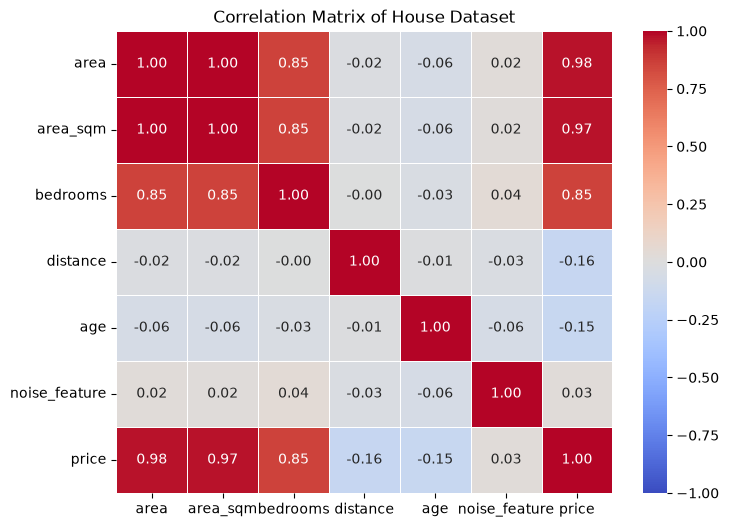

In [2]:
corr_df = df.drop(columns=["constant_col"])   # correlation with a constant is undefined (NaN)
corr = corr_df.corr()

print("Correlation of each feature with price:")
print(corr["price"].drop("price").sort_values(key=abs, ascending=False).round(3))

# Feature-feature pairs with high correlation
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = upper.stack()
high_pairs = high_pairs[high_pairs.abs() > 0.8].sort_values(key=abs, ascending=False)
print("\nHighly correlated pairs (|r| > 0.8):")
print(high_pairs.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of House Dataset")
plt.show()

**Explanation:** We drop the constant column (its correlation is undefined), build the matrix with `df.corr()`, rank features by their absolute correlation with `price`, and list feature pairs above 0.8 using only the upper triangle so each pair appears once.

**Interpretation:** `area` and `area_sqm` are almost perfectly correlated, which shows they are duplicates. `area` and `bedrooms` are also strongly related because bigger houses have more bedrooms. `area` has the strongest link with price, `distance` is negative, and `noise_feature` is close to 0 (useless).

**Important:** the matrix tells us **pairs** only. A feature can be explained by a **combination** of other features without any single high pair. For that we need VIF.

## 2. Multicollinearity

**Definition:** Multicollinearity happens when two or more **input features are strongly related to each other**, so one can be predicted from the others. Perfect multicollinearity means one feature is an exact copy or formula of the others.

**Why is it a problem?**
- In Linear and Logistic Regression, the model cannot decide how to split the credit between related features, so **coefficients become unstable** (they change a lot with small changes in data, and can even flip sign).
- Standard errors grow, so features look "not significant" even when they matter.
- Interpretation breaks down: "effect of area, keeping area_sqm fixed" has no meaning.
- **Predictions are usually still fine.** The damage is mainly to interpretation and stability.

**Causes:** duplicate features in different units, features derived from each other (total = a + b + c), one-hot encoding of all categories (the *dummy variable trap*), or naturally related variables (age and experience).

**How to detect:** correlation matrix (pairs), **VIF** (groups), and unstable coefficients.

**How to fix:** drop one of the related features, combine them (average, ratio), use PCA, or use regularization (Ridge, Lasso).

**Numerical Example:** If y = 2 x1 + 0 x2 and x2 = x1, the model can also write y = 0 x1 + 2 x2 or y = 1 x1 + 1 x2. Infinite answers fit equally well, so the coefficients are not reliable.

**Business Example:** A marketing model uses "TV spend" and "TV spend in thousands". It cannot tell how much sales increase per rupee of TV spending.

**AI/ML Example:** Tree-based models (Random Forest, XGBoost) are not hurt in prediction, but their feature importances get split between correlated features. Linear models are directly affected.

Coefficient of 'area' WITHOUT the duplicate: mean = 0.0482, std = 0.0006
Coefficient of 'area' WITH area_sqm        : mean = 0.0432, std = 0.0038
Coefficient of 'area_sqm'                  : mean = 0.0546, std = 0.0412

R2 without duplicate: 0.9847
R2 with duplicate   : 0.9847


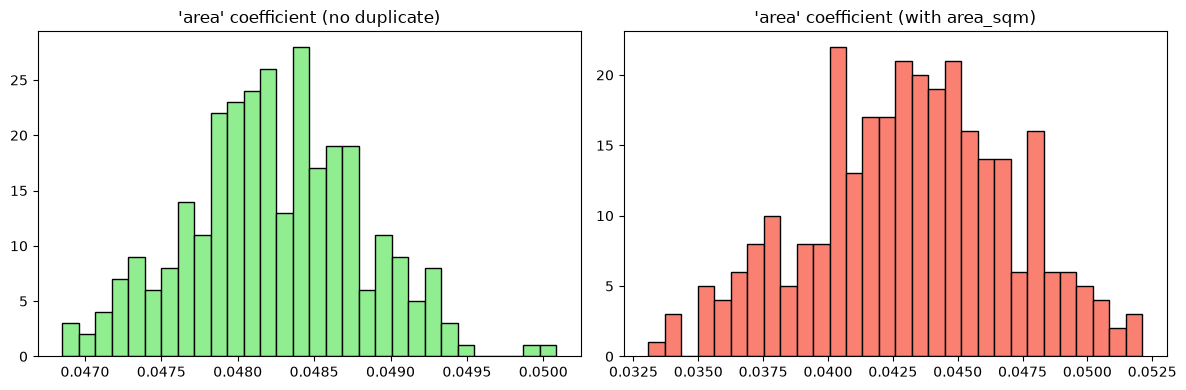

In [3]:
np.random.seed(42)
X_clean = df[["area", "bedrooms", "distance", "age"]]
X_multi = df[["area", "area_sqm", "bedrooms", "distance", "age"]]
y = df["price"]

# Bootstrap: refit the model on 300 resampled datasets and record the coefficients
coef_clean, coef_multi = [], []
for _ in range(300):
    idx = np.random.choice(len(df), len(df), replace=True)
    coef_clean.append(LinearRegression().fit(X_clean.iloc[idx], y.iloc[idx]).coef_[0])
    m = LinearRegression().fit(X_multi.iloc[idx], y.iloc[idx])
    coef_multi.append(m.coef_[:2])

coef_clean = np.array(coef_clean)
coef_multi = np.array(coef_multi)

print("Coefficient of 'area' WITHOUT the duplicate: mean = %.4f, std = %.4f" % (coef_clean.mean(), coef_clean.std()))
print("Coefficient of 'area' WITH area_sqm        : mean = %.4f, std = %.4f" % (coef_multi[:, 0].mean(), coef_multi[:, 0].std()))
print("Coefficient of 'area_sqm'                  : mean = %.4f, std = %.4f" % (coef_multi[:, 1].mean(), coef_multi[:, 1].std()))

# Predictions are almost unaffected
print("\nR2 without duplicate:", round(LinearRegression().fit(X_clean, y).score(X_clean, y), 4))
print("R2 with duplicate   :", round(LinearRegression().fit(X_multi, y).score(X_multi, y), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(coef_clean, bins=30, color="lightgreen", edgecolor="black")
axes[0].set_title("'area' coefficient (no duplicate)")
axes[1].hist(coef_multi[:, 0], bins=30, color="salmon", edgecolor="black")
axes[1].set_title("'area' coefficient (with area_sqm)")
plt.tight_layout()
plt.show()

**Explanation:** We refit the regression on 300 bootstrap resamples (random samples with replacement) and record the coefficient of `area` each time, with and without the duplicate feature `area_sqm`. If a coefficient is stable, it should barely change between resamples.

**Interpretation:** Without the duplicate, the `area` coefficient is tightly clustered around the true value (0.05). With the duplicate, the coefficients of `area` and `area_sqm` vary much more from resample to resample (large standard deviation), because the model keeps shifting credit between the two. The R2 stays almost the same, so **prediction is fine, but the coefficients cannot be trusted**.

## 3. Variance Inflation Factor (VIF)

**Definition:** VIF measures **how much the variance of a coefficient is inflated because of multicollinearity**. For each feature, we try to predict it from all the other features. If the other features predict it very well, it is redundant and its VIF is high.

**Formula:**

$$VIF_j = \frac{1}{1 - R_j^2}$$

where R_j squared is the R-squared of the regression of feature j on all the other features.

**How to read VIF:**

| VIF | Meaning |
|---|---|
| 1 | No relationship with other features |
| 1 to 5 | Acceptable |
| 5 to 10 | Moderate to high, investigate |
| above 10 | Serious multicollinearity (common rule) |

**Numerical Example:**
- R_j squared = 0.50 gives VIF = 1 / 0.50 = **2**
- R_j squared = 0.80 gives VIF = 1 / 0.20 = **5**
- R_j squared = 0.90 gives VIF = 1 / 0.10 = **10**
- R_j squared = 0.99 gives VIF = 1 / 0.01 = **100**

Also, the standard error of the coefficient grows by about sqrt(VIF). VIF = 10 means about 3.2 times larger standard error.

**Business Example:** A pricing analyst checks VIF before building a regression so that the effect of price, discount and promotion spend can be interpreted separately.

**AI/ML Example:** Used during feature selection for Linear and Logistic Regression: remove the feature with the highest VIF, recompute, and repeat until all VIF values are acceptable.

**Advantage over the correlation matrix:** VIF finds a feature that is explained by a **combination** of several features, which pairwise correlation can miss.

**Note:** Compute VIF on numeric features **without the target**. Do not include a constant (it has no meaning for VIF here).

In [4]:
def vif_table(data):
    """VIF of each column = 1 / (1 - R2) from regressing it on the other columns."""
    rows = []
    for col in data.columns:
        others = data.drop(columns=[col])
        r2 = LinearRegression().fit(others, data[col]).score(others, data[col])
        vif = np.inf if r2 >= 0.999999 else 1 / (1 - r2)
        rows.append((col, round(r2, 4), round(vif, 2)))
    return pd.DataFrame(rows, columns=["feature", "R2_from_others", "VIF"]).sort_values("VIF", ascending=False)

features = ["area", "area_sqm", "bedrooms", "distance", "age", "noise_feature"]
print("VIF with all features:")
print(vif_table(df[features]).to_string(index=False))

# Remove the worst feature and recompute (iterative process)
reduced = [f for f in features if f != "area_sqm"]
print("\nVIF after dropping area_sqm:")
print(vif_table(df[reduced]).to_string(index=False))

# Cross-check with statsmodels (optional library)
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    Xc = add_constant(df[features])
    sm_vif = [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])]
    print("\nstatsmodels VIF:", dict(zip(features, np.round(sm_vif, 2))))
except ImportError:
    print("\n(statsmodels not installed. Optional: pip install statsmodels)")

VIF with all features:
      feature  R2_from_others    VIF
         area          0.9950 201.79
     area_sqm          0.9950 201.15
     bedrooms          0.7316   3.73
          age          0.0095   1.01
noise_feature          0.0086   1.01
     distance          0.0024   1.00

VIF after dropping area_sqm:
      feature  R2_from_others  VIF
         area          0.7315 3.72
     bedrooms          0.7311 3.72
          age          0.0079 1.01
noise_feature          0.0059 1.01
     distance          0.0021 1.00

statsmodels VIF: {'area': np.float64(201.79), 'area_sqm': np.float64(201.15), 'bedrooms': np.float64(3.73), 'distance': np.float64(1.0), 'age': np.float64(1.01), 'noise_feature': np.float64(1.01)}


**Explanation:** The function regresses each feature on all the others, takes R-squared, and applies VIF = 1 / (1 - R-squared). We compute VIF for all features, drop the worst one, and compute again. The optional statsmodels line should give nearly the same numbers.

**Interpretation:** `area` and `area_sqm` have a very high VIF (far above 10), because each one is almost perfectly predicted by the other. `bedrooms` has a moderate VIF because it depends on `area`. `distance`, `age` and `noise_feature` are close to 1. After we drop `area_sqm`, the VIF of `area` falls back to a small value. This is the usual workflow: **drop the highest VIF, recompute, repeat**.

**Remember:** VIF checks only relationships **between features**. A feature with VIF = 1 can still be useless for the target (like `noise_feature`). Relevance is checked with feature importance.

## 4. Feature Importance

**Definition:** Feature importance is a score showing **how much each feature contributes to the model's predictions**. It answers: "which features matter most?"

**Common methods:**

| Method | How it works | Notes |
|---|---|---|
| **Correlation with target** | Absolute Pearson/Spearman r | Fast, linear only |
| **Linear model coefficients** | Size of coefficient on **standardized** features | Meaningful only after scaling, unstable with multicollinearity |
| **Tree-based importance** | Total impurity reduction from splits using the feature | Fast, but biased toward features with many unique values |
| **Permutation importance** | Shuffle one feature, measure the **drop in test score** | Model-agnostic, uses held-out data, more reliable |

**Formula (permutation importance):**

$$Importance_j = Score_{original} - Score_{\text{feature } j \text{ shuffled}}$$

**Numerical Example:** Model R2 on test data = 0.90. After shuffling `area`, R2 falls to 0.30, so importance = 0.60. After shuffling `noise_feature`, R2 stays 0.90, so importance = 0.00.

**Business Example:** A bank finds that "income" and "credit history length" are the biggest drivers of loan default predictions and explains this to regulators.

**AI/ML Example:** Model explanation, finding useless features to remove, and debugging (a suspiciously high importance for an ID or timestamp column often means **data leakage**).

**Caution:** When features are correlated, importance gets **shared or split** between them. Each of two duplicate features may look less important than it really is.

               |corr| with price  |std. linear coef|  RF importance  \
area                       0.976              30.973          0.728   
area_sqm                   0.975               5.573          0.238   
distance                   0.159               5.962          0.019   
age                        0.152               3.997          0.010   
noise_feature              0.029               0.468          0.004   
bedrooms                   0.853               2.696          0.001   

               Permutation importance  
area                            0.994  
area_sqm                        0.133  
distance                        0.033  
age                             0.010  
noise_feature                   0.001  
bedrooms                        0.001  

RF test R2: 0.976


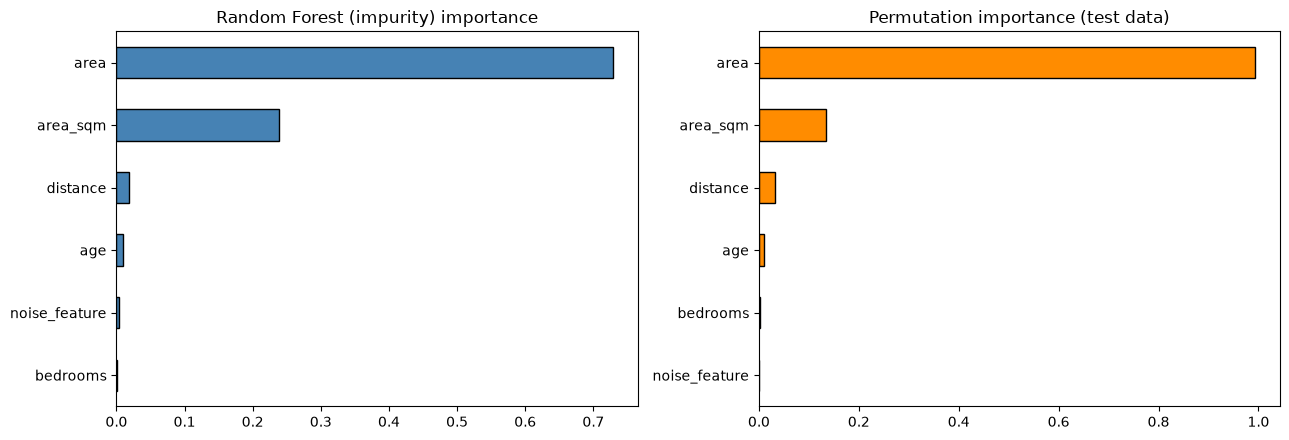

In [5]:
feature_cols = ["area", "area_sqm", "bedrooms", "distance", "age", "noise_feature"]
X = df[feature_cols]
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. Correlation with target
corr_imp = X.corrwith(y).abs()

# 2. Standardized linear coefficients
scaler = StandardScaler().fit(X_train)
lin = LinearRegression().fit(scaler.transform(X_train), y_train)
lin_imp = pd.Series(np.abs(lin.coef_), index=feature_cols)

# 3. Random Forest impurity importance
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
rf_imp = pd.Series(rf.feature_importances_, index=feature_cols)

# 4. Permutation importance (on TEST data)
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=feature_cols)

summary = pd.DataFrame({
    "|corr| with price": corr_imp,
    "|std. linear coef|": lin_imp,
    "RF importance": rf_imp,
    "Permutation importance": perm_imp,
}).round(3).sort_values("RF importance", ascending=False)
print(summary)
print("\nRF test R2:", round(rf.score(X_test, y_test), 3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
rf_imp.sort_values().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Random Forest (impurity) importance")
perm_imp.sort_values().plot(kind="barh", ax=axes[1], color="darkorange", edgecolor="black")
axes[1].set_title("Permutation importance (test data)")
plt.tight_layout()
plt.show()

**Explanation:** We split the data into train and test sets, then calculate importance in four ways: correlation with the target, standardized linear coefficients, Random Forest impurity importance, and permutation importance on the **test set**. All are shown in one table and two bar charts.

**Interpretation:** All methods should agree on the big picture: `area` (and its duplicate), `distance` and `age` carry the signal, and `noise_feature` is near 0. Notice that **the importance of `area` is shared with `area_sqm`**, so each looks smaller than it really is. Permutation importance on test data is usually more trustworthy than impurity importance. If you drop `area_sqm` and re-run, the importance of `area` will rise.

**Good practice:** compare more than one method, remove duplicate features first, and use importance to *guide* decisions, not as proof of cause and effect.

## 5. Feature Selection Basics

**Definition:** Feature selection means **choosing the most useful subset of features** and removing the rest.

**Why do it?**
- Less overfitting, and often better accuracy on new data
- Faster training and prediction
- Simpler, easier-to-explain models
- Lower cost of collecting and storing data

**Three families of methods:**

| Family | Idea | Examples | Speed |
|---|---|---|---|
| **Filter** | Score each feature with a statistic, independent of any model | Variance threshold, correlation, chi-square, ANOVA F-test, mutual information | Fast |
| **Wrapper** | Train the model on different subsets and keep the best | RFE (Recursive Feature Elimination), forward / backward selection | Slow |
| **Embedded** | Selection happens during model training | Lasso (L1) coefficients shrink to 0, tree-based importance | Medium |

**Simple pipeline:**
1. Remove constant / near-constant features (variance threshold)
2. Remove duplicate or highly correlated features (correlation, VIF)
3. Rank features by relevance to the target (F-test, mutual information, importance)
4. Choose the final set using a model (RFE, Lasso) and **cross-validation**

**Numerical Example:** A dataset has 100 features, but only 10 are useful. Keeping all 100 may give 85% test accuracy because of noise. Keeping the best 10 may give 90% with 10 times faster training.

**Business Example:** A telecom company reduces 300 customer attributes to the 25 that actually predict churn, making the model cheaper to run and easier to explain to managers.

**AI/ML Example:** `SelectKBest(f_regression)`, `RFE`, `Lasso`, and tree-based importance are standard tools in scikit-learn.

**Warning:** Do feature selection **inside the training data only** (or inside cross-validation). Selecting features using the whole dataset, including the test set, leaks information.

In [6]:
# Use all 7 columns, including the constant one
all_features = ["area", "area_sqm", "bedrooms", "distance", "age", "noise_feature", "constant_col"]
Xa = df[all_features]
ya = df["price"]
Xa_train, Xa_test, ya_train, ya_test = train_test_split(Xa, ya, test_size=0.3, random_state=42)

# ---- Filter 1: Variance threshold (removes constant features) ----
vt = VarianceThreshold(threshold=0.0).fit(Xa_train)
kept = list(Xa.columns[vt.get_support()])
print("1) Variance threshold keeps:", kept)
print("   Removed:", [c for c in all_features if c not in kept])

Xk_train, Xk_test = Xa_train[kept], Xa_test[kept]

# ---- Filter 2: ANOVA F-test (f_regression) ----
f_sel = SelectKBest(score_func=f_regression, k=4).fit(Xk_train, ya_train)
print("\n2) F-test top 4:", list(Xk_train.columns[f_sel.get_support()]))

# ---- Filter 3: Mutual information (also catches non-linear links) ----
mi = mutual_info_regression(Xk_train, ya_train, random_state=42)
print("\n3) Mutual information scores:")
print(pd.Series(mi, index=Xk_train.columns).round(3).sort_values(ascending=False))

# ---- Wrapper: RFE with a linear model on standardized data ----
sc = StandardScaler().fit(Xk_train)
Xs_train = pd.DataFrame(sc.transform(Xk_train), columns=Xk_train.columns)
rfe = RFE(LinearRegression(), n_features_to_select=4).fit(Xs_train, ya_train)
print("\n4) RFE selects:", list(Xs_train.columns[rfe.support_]))

# ---- Embedded: Lasso (L1) shrinks useless coefficients to 0 ----
lasso = LassoCV(cv=5, random_state=42).fit(Xs_train, ya_train)
lasso_coefs = pd.Series(lasso.coef_, index=Xs_train.columns).round(3)
print("\n5) Lasso coefficients (0 means removed):")
print(lasso_coefs)

# ---- Does selection hurt accuracy? Compare test R2 ----
final_feats = ["area", "bedrooms", "distance", "age"]
r2_all = LinearRegression().fit(Xk_train, ya_train).score(Xk_test, ya_test)
r2_final = LinearRegression().fit(Xa_train[final_feats], ya_train).score(Xa_test[final_feats], ya_test)
print("\nTest R2 with all remaining features:", round(r2_all, 4))
print("Test R2 with selected 4 features    :", round(r2_final, 4))

1) Variance threshold keeps: ['area', 'area_sqm', 'bedrooms', 'distance', 'age', 'noise_feature']
   Removed: ['constant_col']

2) F-test top 4: ['area', 'area_sqm', 'bedrooms', 'age']

3) Mutual information scores:
area             1.467
area_sqm         1.401
bedrooms         0.645
age              0.090
noise_feature    0.036
distance         0.000
dtype: float64

4) RFE selects: ['area', 'area_sqm', 'distance', 'age']

5) Lasso coefficients (0 means removed):
area             31.532
area_sqm          5.002
bedrooms          2.665
distance         -5.915
age              -3.953
noise_feature    -0.421
dtype: float64

Test R2 with all remaining features: 0.9861
Test R2 with selected 4 features    : 0.9866


**Explanation:** We apply five selection methods to the same data. The variance threshold removes the constant column. The F-test and mutual information rank the features by their link with the target. RFE repeatedly removes the weakest feature of a linear model, and Lasso (an embedded method) pushes useless coefficients toward 0. Finally we compare test R2 with all features and with a hand-picked smaller set.

**Interpretation:** The constant column is removed first because it carries no information. `noise_feature` gets a score near 0 in the F-test and mutual information, and Lasso shrinks it to (or very close to) 0. For the duplicate pair `area` and `area_sqm`, the methods may pick either one or both, because they carry the same information, so **we need VIF / correlation checks as well**. The final model with 4 features has almost the same test R2 as the one with all features, but it is **simpler and has no duplicates**.

(Your exact scores can differ slightly. Read your own output and write the interpretation accordingly.)

## Summary

| Concept | Question it answers | Tool | Action |
|---|---|---|---|
| Correlation matrix | Which pairs move together? | `df.corr()`, heatmap | Find duplicates and strong predictors |
| Multicollinearity | Are features redundant with each other? | Correlation matrix, VIF | Drop, combine, PCA or regularize |
| VIF | How well is a feature predicted by the others? | 1 / (1 - R2) | Drop features with VIF above 5 to 10, one at a time |
| Feature importance | Which features matter for the target? | Permutation, tree, coefficients | Understand and prune the model |
| Feature selection | Which subset should we keep? | Filter, wrapper, embedded | Keep a small, useful, non-redundant set |

**Two different checks, do both:**
- **Relevance:** is the feature useful for the *target*? (correlation with target, importance, F-test)
- **Redundancy:** is the feature a copy of *other features*? (feature-feature correlation, VIF)

## Advantages
- Removes noise and duplicate information, which reduces overfitting
- Gives more stable, interpretable models (especially linear models)
- Faster training and cheaper deployment
- Helps explain to business teams which factors drive the predictions

## Limitations
- Correlation only captures linear, pairwise relationships
- VIF cannot detect irrelevant features, and it is mainly useful for linear models
- Importance scores get split between correlated features, and impurity-based importance is biased toward features with many unique values
- Feature importance shows association, not cause and effect
- Selecting features on the full dataset (before the train-test split) causes data leakage
- A feature that is weak alone can be strong in combination with another (interaction), and simple filters can drop it